# AP 155 Lab Exercise
---
## Exercise 6: Eigenfunctions and Eigenvalues of a Hamiltonian

_Instructions_: 
- **Problem 1 Report figure:** First 5 wavefunctions of the harmonic oscillator.
- **Problem 2 Report figure:** Energy analysis and plotting of probability density.
- **Report Discussion:**  In problem 2, why is the expected result as so? Did you get the expected result in both eigenenergies and ground state wavefunction? why or why not
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Botron, Christan Jake
- _Student No._: 2024-10168
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

<img src="Figures/problem1.png" alt="Problem 1 output" width=45%>  

**Figure 1:** The first five energy eigenstates ($n=0$ to $4$) of the unperturbed quantum harmonic oscillator ($\omega=0.8$).

<img src="Figures/problem2a.png" alt="Problem 2a" width=45%> <img src="Figures/problem2b.png" alt="Problem 2b" width=45%>

**Figure 2:** (Left, a) Comparison of the first 100 numerical and theoretical eigenenergies for the perturbed oscillator. Notice the quadratic divergence at high $n$ caused by spatial truncation at the numerical grid boundaries. (Right, b) The effective potential $V(x)$ and ground state probability density $\vert{}\psi_0\vert{}^2$. The uniform electric field shifts the potential well and the Gaussian probability density peak precisely to the new physical minimum at $x = -1.0$.

### Report discussion

The finite-difference Hamiltonian accurately models both the unperturbed and perturbed quantum harmonic oscillator. For the unperturbed system, I set the spatial domain to $x \in [-10, 10]$ instead of the prescribed $[-3, 3]$ in class to ensure the wavefunctions decay naturally without artificial boundary restriction (as I have noticed with the initial bounds). This correctly resolves the expected nodal structure, alternating parity, and equidistant energy spacing of $\Delta E = 0.8$ for the lowest eigenstates as (Figure 1). Now, introducing a uniform electric field applies a linear perturbation, $qEx$, which algebraically completes the square of the potential, i.e.,
$$
\begin{align*}  
V(x) &= \frac{1}{2}m\omega^2x^2 + qEx \\  
&= \frac{1}{2}m\omega^2 \left( x^2 + \frac{2qE}{m\omega^2}x \right) \\  
&= \frac{1}{2}m\omega^2 \left( x + \frac{qE}{m\omega^2} \right)^2 - \frac{q^2E^2}{2m\omega^2}  
\end{align*}
$$
This dynamically shifts the harmonic well downward and horizontally by $\Delta x = -\frac{qE}{m\omega^2}$ without altering the intrinsic restoring force $\omega$. This is shown in the calculated numerical ground state, maintaining its theoretical Gaussian profile while centering precisely on the new effective minimum at $x = -1.0$ as seen in Figure 2b. For Problem 2a, the numerical eigenenergies strongly agree with the theoretically predicted uniform downward shift for lower energy states ($n \le 50$) as seen in Figure 2a. However, significant divergence occurs at higher quantum numbers. Because highly excited states expand beyond the $x = \pm 10$ grid, the numerical boundaries act like rigid walls which confines the system to a sort of infinite well, forcing the calculated energies to grow quadratically rather than linearly.

### Other comments
- No comments.


---
## Section 2: Code

### Problem 1: Hamiltonian Matrix and its Eigs

The time-independent Schrödinger equation is:

$$
\left[-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}+\hat{V}(x)\right]\psi(x)=\left[\hat{T} + \hat{V} \right]\psi=\mathscr{E}_n\psi(x).
$$

In quantum mechanics, we can represent operators (e.g. $\hat{T}$ and $\hat{V}$) as matrices, while the quantum state (in this case, $\psi$) is written as an $N \times 1$ vector

$$ \psi = 
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix}
$$

where $\psi_i$ represents the value of the wave function at $x_i$. Now, we know that $\left[\hat{V}(x)\psi(x)\right]|_{x_i} \equiv V(x_i)\psi(x_i) = V_i \psi_i$. We can write this statement as:

$$\hat{V}
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = 
\begin{bmatrix}
V_1\psi_1 \\
V_2\psi_2 \\
\vdots \\
V_i\psi_i \\
\vdots \\
V_N\psi_N
\end{bmatrix}
$$

This relation only holds true when $\hat{V}$ is an $N \times N$ square diagonal matrix of the form:

$$
\boxed{\hat{V}=
\begin{pmatrix}
V_1 & 0 & 0 & \cdots & 0 & 0 & 0 \\
0 & V_2 & 0 & \cdots & 0 & 0 & 0 \\
0 & 0 & V_3 & \cdots & 0 & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & 0 & \cdots & V_i & 0 & 0 \\
0 & 0 & 0 & \cdots & 0 & \ddots & 0 \\
0 & 0 & 0 & \cdots & 0 & 0 & V_N
\end{pmatrix}
}
$$

where $V_i$ denotes the potential's value at $x_i$. This is then what we call the "matrix representation" of the operator $\hat{V}$! At least, in the position basis -- more info on 142 or 241 :)

**(a)** On a piece of paper, find the matrix representation of the kinetic energy operator $\hat{T} \equiv \cfrac{-\hbar^2}{2m}\cfrac{\partial^2}{\partial x^2}$. Use the fact that 

$$
f''(x_i)=
\frac{f(x_{i+1}) - 2f(x_i) + f(x_{i-1})}{(\Delta x)^2}
$$

The first step of this problem would be to solve
$$
\cfrac{\partial^2}{\partial x^2}\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = \ ?
$$

and then to find a matrix representation for $\cfrac{\partial^2}{\partial x^2}$ operator. Your result should look like a square diagonal matrix

$$
\boxed{\hat{T}=
-\frac{\hbar^2}{2m(\Delta x)^2}
\begin{pmatrix}
-2 & 1 & 0 & 0 & 0 & \cdots & 0 \\
1 & -2 & 1 & 0 & 0 & \cdots & 0 \\
0 & 1 & -2 & 1 & 0 & \cdots & 0 \\
0 & 0 & 1 & -2 & 1 & \ddots & \vdots \\
0 & 0 & 0 & 1 & -2 & \ddots & 0 \\
\vdots & \vdots & \vdots & \ddots & \ddots & \ddots & 1 \\
0 & 0 & 0 & \cdots & 0 & 1 & -2
\end{pmatrix}
}
$$

**(b)** Write a function that outputs the Hamiltonian ($\hat{T} + \hat{V})$ matrix `hamiltonian(x_pos, potential_array, mass)` where `x_pos` and `potential_array` are both $N \times 1$ arrays (vectors), while `mass` is a scalar. The former represents position coordinates while the latter represents potential values at these coordinates. You might want to use `np.eye()`.

**(c)** Test your `hamiltonian()` function for the case where $V(x) = \cfrac{1}{2}m\omega^2x^2$. Obtain the first $N=5$ eigenfunctions of your Hamiltonian using `np.linalg.eigh()`, and obtain their corresponding eigenvalues. Plot the eigenfunctions, then offset each to its corresponding eigenvalue. In essence, you will plot $f_n$ where

$$
f_n = \psi_n + \mathscr{E}_n
$$

Lastly, overlay the harmonic potential $V$ on the plot itself. Assume that $m=\hbar=1$ while $\omega=0.8$. 

<img src="Figures/problem1a.jpg" alt="Problem 1 output" width=45%>  

Handwritten Solution for Problem 1a.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Eigenvectors:
[[ 1.18651106e-19 -1.78808655e-18  1.30072707e-17  9.22139359e-17
  -5.66850900e-16]
 [ 2.40339286e-19 -3.80808808e-18  2.63283100e-17  1.86377742e-16
  -1.14661538e-15]
 [ 3.67886771e-19 -5.26007460e-18  4.02744848e-17  2.85645768e-16
  -1.75231686e-15]
 ...
 [ 3.67902553e-19  5.86739723e-18  4.02747023e-17 -2.84849980e-16
  -1.75231830e-15]
 [ 2.40364179e-19  3.82191854e-18  2.63288076e-17 -1.86306326e-16
  -1.14661771e-15]
 [ 1.18598653e-19  1.77898095e-18  1.30060195e-17 -9.22130888e-17
  -5.66838137e-16]]

Eigenvalues:
[0.39999198 1.19995992 1.99989579 2.79979958 3.59967131]


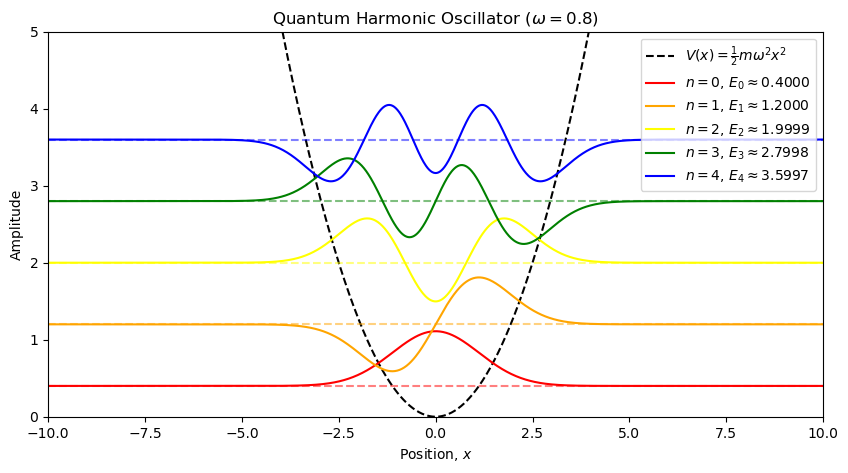

In [2]:
#test parameters 
m = 1
omega = 0.8
test_x_pos_a = np.linspace(-10,10,1000) #test x_pos
test_potential = 0.5 * m * omega**2 * test_x_pos_a**2 #given in (c)
dx_1 = test_x_pos_a[1] - test_x_pos_a[0] #should be fixed

#---------------------------------------------------#

def hamiltonian(x_pos, potential_array, mass, hbar=1): #default hbar=1 (natural units)
    dx = x_pos[1] - x_pos[0]
    
    main_diag = -2 * np.eye(len(x_pos), k=0)
    upper_diag = 1 * np.eye(len(x_pos), k=1)
    lower_diag = 1 * np.eye(len(x_pos), k=-1)
    
    T_hat = -(hbar**2 / (2 * mass * dx**2)) * (main_diag + upper_diag + lower_diag) 
    V_hat = np.diag(potential_array)
    
    return T_hat + V_hat

#---------------------------------------------------#

test_H = hamiltonian(test_x_pos_a, test_potential, m)

eigenvalues, eigenvectors = np.linalg.eigh(test_H)
first5_E = eigenvalues[:5]
first5_psi = eigenvectors[:, :5] #all rows, from 0th -> 5th row

print("Eigenvectors:")
print(first5_psi)
print()
print("Eigenvalues:")
print(first5_E)

first5_psi_normalized = first5_psi / np.sqrt(dx_1)

plt.figure(figsize=(10, 5))

#overlay of harmonic potential V
plt.plot(test_x_pos_a, test_potential, color='black', linestyle='--', linewidth=1.5, label=r'$V(x) = \frac{1}{2}m\omega^2 x^2$')

colors = ['red', 'orange', 'yellow', 'green', 'blue']
for i in range(5):
    E_n = first5_E[i]
    psi_n = first5_psi_normalized[:, i] 

    #print(psi_n.max())
    
    if psi_n.max() < 0: #goofy code to resolve issue with f_0 plot
        psi_n = -psi_n
    else:
        pass
    
    f_n = psi_n + E_n #from hint in c
    
    plt.plot(test_x_pos_a, f_n, color=colors[i], label=f'$n={i}$, $E_{i} \\approx {E_n:.4f}$') #f_n plot
    plt.axhline(E_n, color=colors[i], linestyle='--', alpha=0.5) #energy level plot
    
plt.xlabel('Position, $x$')
plt.ylabel('Amplitude')
plt.title(r'Quantum Harmonic Oscillator ($\omega=0.8$)')
plt.xlim(-10, 10)
plt.ylim(0, 5)
plt.legend()

plt.savefig('Figures/problem1.png', dpi=300, bbox_inches='tight')
plt.show()

#### Problem 1 code summary

The first part in my code for problem 1 defines a function that generates the Hamiltonian of the system by combining the derived matrix expression of the kinetic energy operator with the diagonal potential matrix. I then used the np.linalg.eigh() function to solve for the eigenvalues and eigenvectors. I then normalized the wavefunctions and visualized the first five energy eigenstates by plotting them offset by their respective energy levels alongside the harmonic potential. A problem was encountered, however, where the ground state was "inverted," that is, it was under the potential curve and was a valley rather than a hill. To fix that, I used an if-statement to invert it s.t. it becomes positive.

---

### Problem 2: Harmonic Oscillator in an Electric Field

The effective potential of an oscillator immersed in a uniform electric field is

$$
V(x) = \cfrac{1}{2}m\omega^2x^2 + qEx
$$

where $q$ is the particle's charge, and $E$ is the strength of the applied uniform electric field.

**(a)** Assume that the particle is an electron and it is immersed in a field of strength $E=q^{-1}$. Plot 100 eigenenergies of the resulting Hamiltonian, and compare it with the theoretical value of

$$
\mathscr{E}_n = \hbar \omega \left(n+\cfrac{1}{2} \right) - \cfrac{q^2 E^2}{2m \omega^2}
$$

Did you get the expected result? Why or why not?

**(b)** Plot the potential and the probability density of the ground state. Does the plot make sense? 

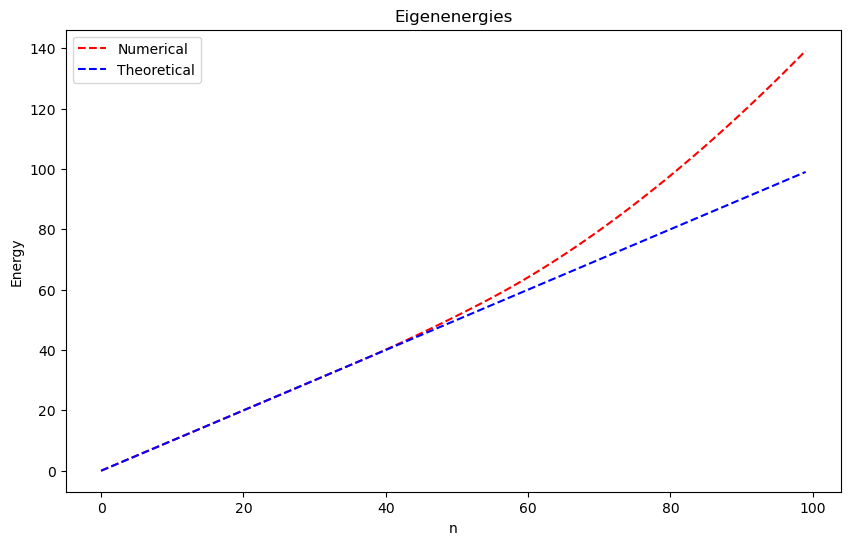

In [3]:
#Given:
hbar = 1
m = 1
omega = 1
hbar = 1
qE = 1

test_x_pos_b = np.linspace(-10,10,1000)
test_potential_b = 0.5 * m * omega**2 * test_x_pos_b**2 + ((qE) * test_x_pos_b) #q*E = q*q^-1 = 1
dx_2 = test_x_pos_b[1] - test_x_pos_b[0]

H_b = hamiltonian(test_x_pos_b, test_potential_b, m) #gets the hamiltonian using the function in (a)
eigenvalues_b, eigenvectors_b = np.linalg.eigh(H_b)
numerical_E = eigenvalues_b[:100] #first 100 E's solved numerically

n_array = np.arange(100) #n=0 to n=99
theoretical_E = hbar * omega * (n_array + 0.5) - ((qE)**2 / (2 * m * omega**2)) #E_n = hbar * omega * (n + 0.5) - (q^2 E^2) / (2 m omega^2); q^2 E^2 = 1; first 100 E's solved theoretically

plt.figure(figsize=(10, 6))
plt.plot(n_array, numerical_E, color='red', linestyle='--', label='Numerical')
plt.plot(n_array, theoretical_E, color='blue', linestyle='--', label='Theoretical')

plt.xlabel('n')
plt.ylabel('Energy')
plt.title('Eigenenergies')
plt.legend()

plt.savefig('Figures/problem2a.png', dpi=300, bbox_inches='tight')
plt.show()

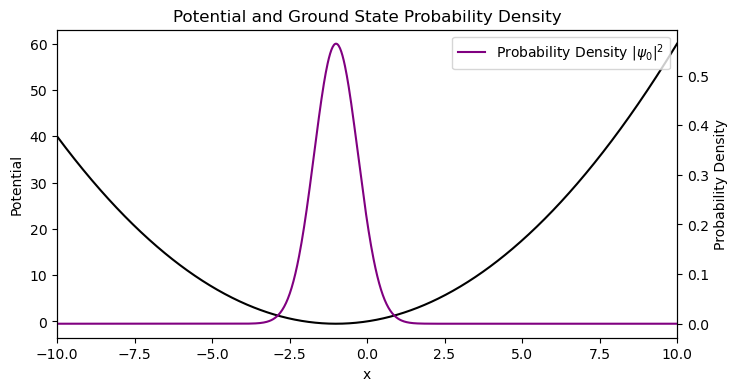

In [8]:
psi_0 = eigenvectors_b[:, 0] / np.sqrt(dx_2) #normalized
prob_density = np.abs(psi_0)**2

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(test_x_pos_b, test_potential_b, color='black', label=r'Potential $V(x)$')
ax1.set_ylabel('Potential')
ax1.set_xlabel('x')

ax2 = ax1.twinx()
ax2.plot(test_x_pos_b, prob_density, color='purple', label=r'Probability Density $|\psi_0|^2$')
ax2.set_ylabel('Probability Density')

plt.title('Potential and Ground State Probability Density')
plt.xlim(-10, 10)

plt.legend()

plt.savefig('Figures/problem2b.png', dpi=300, bbox_inches='tight')
plt.show()

#### Problem 2 code summary

For this problem, my code is similar to Problem 1 where it computes the numerical eigenenergies for a quantum harmonic oscillator in a uniform electric field and plots the first 100 energy levels. I also computed the their theoretical counterparts to compare their results. For part b, it extracts and normalizes the ground state wavefunction (similar to problem 1) to visualize its probability density directly over the tilted potential energy profile.

---

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)